## XGBoost

`XGBoost (Extreme Gradient Boosting)` is a **high-performance ensemble learning
algorithm** based on Gradient Boosting.
It is designed to be **faster, more efficient, and more accurate** than
traditional gradient boosting methods.

XGBoost is one of the most popular algorithms in machine learning competitions
and real-world applications.

---

### What It Is

XGBoost:
- Builds models sequentially like Gradient Boosting
- Uses decision trees as base learners
- Adds regularization to control overfitting
- Is optimized for speed and performance

It improves predictions by learning from previous errors.

---

### Why It Is Used

XGBoost is used because:
- It delivers state-of-the-art performance
- It handles large datasets efficiently
- It reduces overfitting using regularization
- It is highly optimized and scalable

---

### Where It Is Used

XGBoost is widely used in:
- Kaggle competitions
- Finance and risk modeling
- Recommendation systems
- Classification and regression tasks

---

### When It Performs Well

XGBoost performs well when:
- Dataset is medium to large
- Features are well-engineered
- Data is structured (tabular)
- High accuracy is required

---

### When It Performs Poorly

XGBoost performs poorly when:
- Dataset is very small
- Data is extremely noisy
- Features are poorly prepared
- Hyperparameters are not tuned

---

### Advantages

- Very high accuracy
- Fast training and prediction
- Built-in regularization
- Handles missing values well

---

### Limitations

- Complex hyperparameters
- Requires tuning for best results
- Less interpretable than simple models
- Overkill for simple problems

---

### Key Takeaways

- XGBoost is an optimized form of Gradient Boosting
- Widely used in competitions and industry
- Powerful but complex
- Best suited for structured data


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [3]:
from xgboost import XGBClassifier

In [4]:
X, y = make_classification(
    n_samples=500,
    n_features=2,          # 2D → decision boundary visualization
    n_informative=2,
    n_redundant=0,
    n_classes=2,
    random_state=42
)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)


In [6]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [7]:
y_pred = xgb.predict(X_test)
y_prob = xgb.predict_proba(X_test)[:, 1]


In [8]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.872
ROC-AUC: 0.9548131080389145

Confusion Matrix:
 [[51 11]
 [ 5 58]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.82      0.86        62
           1       0.84      0.92      0.88        63

    accuracy                           0.87       125
   macro avg       0.88      0.87      0.87       125
weighted avg       0.88      0.87      0.87       125



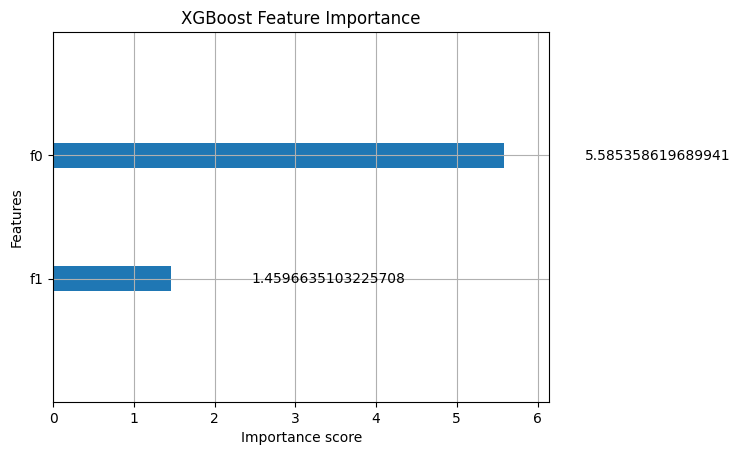

In [10]:
from xgboost import plot_importance

plot_importance(xgb, importance_type="gain")
plt.title("XGBoost Feature Importance")
plt.show()



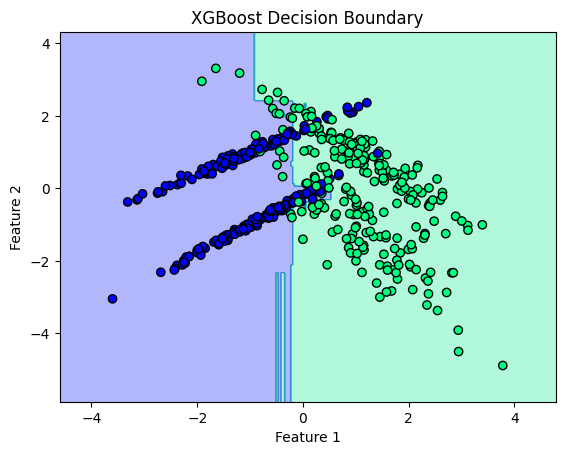

In [11]:
x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

Z = xgb.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='winter')
plt.scatter(X[:,0], X[:,1], c=y, cmap='winter', edgecolor='k')
plt.title("XGBoost Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()
